# Working with CEH-GEAR-1hr rainfall data
## Zarr version using R

**Launch this notebook**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/NERC-CEH/fdri-gridded-notebooks/blob/main/notebooks/CEH-GEAR-1hr/gear_zarr_R.ipynb)
[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/NERC-CEH/fdri-gridded-notebooks/HEAD?labpath=notebooks/CEH-GEAR-1hr/gear_zarr_R.ipynb)

(Ctrl + Click to open in a new tab)

> **Google Colab:** If running in Google Colab, you will need to switch to an R runtime. Click the "Runtime" menu in the menu bar at the top of the screen, select Change runtime type, select R from the 'Runtime type' drop down box, you can leave the rest the same.

Full instructions available in the [accompanying README](https://github.com/NERC-CEH/fdri-gridded-notebooks/blob/main/README.md#R).

---

## About this notebook

This notebook explores **CEH-GEAR-1hr** (Gridded Estimates of Areal Rainfall — Hourly), a gridded rainfall dataset for Great Britain produced as part of the [FDRI (Floods and Droughts Research Infrastructure)](https://fdri.org.uk) project.

Simple examples are shown for exploring and working with the dataset, which can be generalised to any gridded dataset stored on S3 storage, a storage medium that is becoming increasingly common for large gridded datasets. Datasets on S3 storage are typically stored in the Zarr format.

**We will:**
1. Show how to open a dataset stored in Zarr format
2. Show how to extract and plot a time series at a single location
3. Show how to plot a map of rainfall at a single time step

**Data store:**
The data is currently publicly available as a trial through JASMIN object storage at the following URL:
```
https://fdri-o.s3-ext.jc.rl.ac.uk/gearhrly/gearhrly_15day_100km_chunks.zarr
```

---

## 0. Setup

Install and load the `zarr` package and plotting libraries.
The first cell is a workaround for installing the `terra` library needed for map plotting on Google Colab, it is unlikely to work on other platforms, is not needed when using Binder, and takes up to 15mins to run. Package installation of all the other packages can take a similar amount of time.

In [ ]:
locks <- list.files("/usr/local/lib/R/site-library", pattern = "^00LOCK", full.names = TRUE)
unlink(locks, recursive = TRUE)

# Step 1: Set up r2u for installing terra (uses precompiled binaries to bypass gdal problems)
download.file(
  "https://github.com/eddelbuettel/r2u/raw/master/inst/scripts/add_cranapt_focal.sh",
  "add_cranapt_focal.sh"
)
Sys.chmod("add_cranapt_focal.sh", "0755")
system("./add_cranapt_focal.sh")

# Step 2: Now install terra normally using the precompiled binary
install.packages("terra", verbose=TRUE, keep_output=TRUE)
library(terra)

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

system (cmd0): /usr/lib/R/bin/R CMD INSTALL

foundpkgs: terra, /tmp/RtmpT0CcnQ/downloaded_packages/terra_1.9-11.tar.gz

files: /tmp/RtmpT0CcnQ/downloaded_packages/terra_1.9-11.tar.gz



In [ ]:
# ── Install packages ──────────────────────────────────────────────────────────
pkgs <- c("zarr", "curl", "ggplot2", "dplyr", "tidyr", "sf", "rnaturalearth",
          "rnaturalearthdata", "scales", "lubridate")
new  <- pkgs[!pkgs %in% installed.packages()[, "Package"]]
if (length(new) > 0) install.packages(new, repos = "https://cloud.r-project.org", verbose = TRUE)

# ── Load ──────────────────────────────────────────────────────────────────────
suppressPackageStartupMessages({
  library(zarr)             # Native Zarr v3 driver
  library(ggplot2)          # Plotting
  library(dplyr)            # Data wrangling
  library(tidyr)
  library(sf)               # Spatial features
  library(rnaturalearth)    # Country/coastline outlines
  library(rnaturalearthdata)
  library(scales)           # Axis formatting
  library(lubridate)        # Date handling
})

cat("zarr version:", as.character(packageVersion("zarr")), "\n")

zarr version: 0.3.0 


---
## 1. Open the Zarr store

The `zarr` package opens HTTP stores with `open_zarr()`. For Zarr v2 stores that have a consolidated `.zmetadata` file at the root, the package automatically reads the full hierarchy. Otherwise it queries the store's root for a `zarr.json` (v3) or `.zarray` (v2) file.

> **Note**: The `zarr` package handles HTTP stores as **read-only** automatically.

In [ ]:
# ── Store URL ─────────────────────────────────────────────────────────────────
store_url <- "https://fdri-o.s3-ext.jc.rl.ac.uk/gearhrly/gearhrly_15day_100km_chunks.zarr"

# Open the store — zarr handles HTTP natively, no credentials needed for public stores
dataset <- open_zarr(store_url)

# Print the top-level summary
print(dataset)

Warning message:
“Error reading metadata from location crs. Ignoring.”


<Zarr>
Version   : 2 
Store     : HTTP store 
Arrays    : 11 

Attributes:
 name                        
 Conventions                 
 acknowledgement             
 cdm_data_type               
 contributor_name            
 coordinates                 
 creator_email               
 creator_institution         
 creator_name                
 geospatial_lat_max          
 geospatial_lat_min          
 geospatial_lon_max          
 geospatial_lon_min          
 id                          
 institution                 
 keywords                    
 licence                     
 metadata_link               
 naming_authority            
 publisher_institution       
 references                  
 source                      
 spatial_resolution_distance 
 spatial_resolution_unit     
 standard_name_url_vocabulary
 standard_name_vocabulary    
 summary                     
 time_coverage_duration      
 time_coverage_resolution    
 title                       
 version                 

This information isn't displayed particularly helpfully, so we can improve on that below:

---
## 2. Get more information about the dataset

### List variables

The `$hierarchy()` method shows all the variables available in the dataset

In [ ]:
# Print the full store hierarchy (the variables available are shown next to a ⌗ symbol)
dataset$hierarchy()

<Zarr hierarchy> https://fdri-o.s3-ext.jc.rl.ac.uk/gearhrly/gearhrly_15day_100km_chunks.zarr 
☰ / (root group)
├ ⌗ lat
├ ⌗ lon
├ ⌗ min_dist
├ ⌗ rainfall_amount
├ ⌗ stat_disag
├ ⌗ time
├ ⌗ time_bnds
├ ⌗ x
├ ⌗ x_bnds
├ ⌗ y
└ ⌗ y_bnds


### Show dataset-level metadata


In [ ]:
# Get the root group's attributes
root_attrs <- dataset[["/"]]$attributes

for (nm in names(root_attrs)) {
  val <- paste(unlist(root_attrs[[nm]]), collapse = ", ")
  cat(sprintf("  %-30s : %s\n", nm, val))
}

  Conventions                    : CF-1.6
  acknowledgement                : This research forms part of the SINATRA project which is supported by the United Kingdom NERC Flooding from Intense Rainfall programme (grant NE/K00896X/1) and an associated knowledge exchange award. It was also funded as part of the CONVEX project which was supported by the United Kingdom NERC Changing Water Cycle programme (grant NE/I006680/1) and the INTENSE project through the European Research Council (grant ERC-2013-CoG-617329). The update of CEH-GEAR-1hr (version 2) was funded by NERC Hydro?JULES programme (grant NE/S017380/1)
  cdm_data_type                  : Grid
  contributor_name               : Lewis, E., Quinn, N., Blenkinsop, S., Fowler, H.J., Freer, J., Tanguy, M., Hitt, O., Coxon, G., Bates, P., Woods, R., Fry, M., Chevuturi, A., Swain, O., White, S.M.
  coordinates                    : time_bnds x_bnds y_bnds
  creator_email                  : enquiries@ceh.ac.uk
  creator_institution        

### See details of each specific variable

Arrays are accessed using `dataset[["path"]]` syntax. Each array object exposes its shape, chunking, data type, and attributes.

In [ ]:
# ── Inspect each array in the store ──────────────────────────────────────────
# We use z$arrays to iterate; path must start with "/"

for (arr_path in dataset$arrays) {
  arr <- dataset[[arr_path]]
  cat(sprintf("\n╔══ %s ══╗\n", arr_path))
  cat(sprintf("  Data type : %s\n", arr$data_type$data_type))
  cat(sprintf("  Shape     : %s\n", paste(arr$shape, collapse = " × ")))

  # Print any attributes
  attrs <- arr$attributes
  if (length(attrs) > 0) {
    cat("  Attributes:\n")
    for (nm in names(attrs)) {
      val <- paste(unlist(attrs[[nm]]), collapse = ", ")
      cat(sprintf("    %-20s : %s\n", nm, val))
    }
  }
}


╔══ /lat ══╗
  Data type : float64
  Shape     : 1251 × 701
  Attributes:
    _ARRAY_DIMENSIONS    : y, x
    long_name            : latitude
    standard_name        : latitude
    units                : degrees_north

╔══ /lon ══╗
  Data type : float64
  Shape     : 1251 × 701
  Attributes:
    _ARRAY_DIMENSIONS    : y, x
    long_name            : longitude
    standard_name        : longitude
    units                : degrees_east

╔══ /min_dist ══╗
  Data type : float64
  Shape     : 236688 × 1251 × 701
  Attributes:
    _ARRAY_DIMENSIONS    : time, y, x
    comment              : The minimum distance corresponds to the distance to the closest raingauge used in the nearest neighbour method to estimate the normalised hourly rainfall amount in a grid cell. This distance provides an indicator of accuracy/confidence in the estimated rainfall amount. As the minimum distance increases so does uncertainty in the rainfall estimates. Users should be cautious when using the rainfall data 

### Read coordinate arrays

Adjust the variables after the function definition below to match what dataset$arrays printed above.

In [ ]:
# ── Read coordinate arrays ────────────────────────────────────────────────────

read_coord <- function(dataset, path) {
  tryCatch({
    arr <- dataset[[path]]
    # Empty index reads all values
    as.numeric(arr[])
  }, error = function(e) {
    message("  Could not read '", path, "': ", conditionMessage(e))
    NULL
  })
}

# Adjust these paths to match what dataset$arrays printed above
# Common names: /time, /lat, /lon, /latitude, /longitude, /x, /y
cat("Reading coordinates...\n")
lons  <- read_coord(dataset, "/lon")
lats  <- read_coord(dataset, "/lat")
xs  <- read_coord(dataset, "/x")
ys  <- read_coord(dataset, "/y")
times <- read_coord(dataset, "/time")

# ── Decode time axis ──────────────────────────────────────────────────────────
# Get units from the time array's attributes
time_arr   <- dataset[["/time"]]
time_attrs <- time_arr$attributes
time_units <- time_attrs[["units"]]
time_cal   <- time_attrs[["calendar"]]

cat("Time units  :", time_units, "\n")
cat("Calendar    :", if (is.null(time_cal)) "(not specified, assuming gregorian)" else time_cal, "\n")

# Parse "hours since YYYY-MM-DD HH:MM:SS" style CF units
origin_str <- sub(".*since\\s+", "", time_units)
origin_dt  <- as.POSIXct(origin_str, tz = "UTC",
                format = ifelse(grepl(":", origin_str), "%Y-%m-%d %H:%M:%S", "%Y-%m-%d"))

# Determine units multiplier (hours → seconds; days → seconds; etc.)
unit_word  <- tolower(sub("\\s+since.*", "", time_units))
multiplier <- switch(unit_word,
  "hours"   = 3600,
  "days"    = 86400,
  "minutes" = 60,
  "seconds" = 1,
  3600  # default to hours
)

datetimes <- origin_dt + as.numeric(times) * multiplier

cat(sprintf("\nLon   : %d values, %.3f° to %.3f°\n",
  length(lons), min(lons), max(lons)))
cat(sprintf("Lat    : %d values, %.3f° to %.3f°\n",
  length(lats), min(lats), max(lats)))
cat(sprintf("x  : %d values, %.3f to %.3f\n",
  length(xs), min(xs), max(xs)))
cat(sprintf("y    : %d values, %.3f to %.3f\n",
  length(ys), min(ys), max(ys)))
cat(sprintf("Time steps  : %d, from %s to %s\n",
  length(datetimes), format(min(datetimes)), format(max(datetimes))))

Reading coordinates...
Time units  : hours since 1980-01-01 
Calendar    : gregorian 

Lon   : 876951 values, -9.392° to 3.552°
Lat    : 876951 values, 49.767° to 61.132°
x  : 701 values, 0.000 to 700000.000
y    : 1251 values, 0.000 to 1250000.000
Time steps  : 236688, from 1990-01-01 to 2016-12-31 23:00:00


## Read in a specific data variable

Set `data_var` to the name of the rainfall (or other of interest) variable in the dataset.

In [ ]:
# Set to the main data variable — adjust based on what dataset$arrays showed above if necessary
data_var <- "rainfall_amount"   # <-- adjust if needed

data_arr   <- dataset[[paste0("/", data_var)]]
data_attrs <- data_arr$attributes

cat("=== Data variable:", data_var, "===\n")
cat("Shape  :", paste(data_arr$shape, collapse = " × "), "\n")

# Print attributes
for (nm in names(data_attrs)) {
  cat(sprintf("  %-20s : %s\n", nm, paste(unlist(data_attrs[[nm]]), collapse = ", ")))
}

# Extract units and long name for plot labels
var_units <- data_attrs[["units"]] %||% ""
var_long  <- data_attrs[["long_name"]] %||% data_attrs[["standard_name"]] %||% data_var

=== Data variable: rainfall_amount ===
Shape  : 236688 × 1251 × 701 
  _ARRAY_DIMENSIONS    : time, y, x
  coordinates          : lon lat
  grid_mapping         : crs
  long_name            : Gridded estimates of hourly rainfall
  standard_name        : rainfall_amount
  units                : kg m-2
  valid_max            : 500
  valid_min            : 0


---
## 3. Time series at a single grid point

We use R's $read method on the Zarr array object to extract out the data we want. The `zarr` package translates this to efficient HTTP range requests — only the relevant chunks are actually fetched from the cloud store. This sort of indexing is simpler in Python where we can use the more fully developed xarray package.

**A brief note on chunking:** This store uses 15-day × 100km chunks (as indicated in the filename). A single point time series will download only the chunks that contain the data we've requested.

In [ ]:
# ── Choose a target location ──────────────────────────────────────────────────
# Default: Edinburgh, Scotland
target_x <- 500000
target_y <- 200000

# Find the nearest grid cell indices
i_x <- unname(which.min(abs(xs - target_x)))
i_y <- unname(which.min(abs(ys - target_y)))

cat(sprintf("Target location  : x=%.3f, y=%.3f\n", target_x, target_y))
cat(sprintf("Nearest grid cell: x=%.3f (index %d), y=%.3f (index %d)\n",
  xs[i_x], i_x, ys[i_y], i_y))

Target location  : x=500000.000, y=200000.000
Nearest grid cell: x=500000.000 (index 501), y=200000.000 (index 1051)


Read the first 1000 time steps for this grid cell

In [ ]:
# ── Read the full time series for this grid cell ──────────────────────────────
# Zarr array indexing in R: arr[dim1_indices, dim2_indices, dim3_indices, ...]
# Empty index (or NULL) = all elements along that dimension
# Dimension order: check data_arr$shape against coord lengths to confirm

n_time <- 1000

cat(sprintf("Reading %d time steps for grid cell [%d, %d]...\n",
  n_time, i_y, i_x))

# Typical xarray-written Zarr dim order: [time, y, x]
# Adjust index order if your array has a different convention
# Check in the metadata readouts above
n_time <- as.integer(n_time)
i_y <- as.integer(i_y)
i_x <- as.integer(i_x)
ts_raw <- data_arr$read(selection = list(seq_len(n_time), i_y, i_x))
ts_vals <- as.numeric(ts_raw)

# Build a data frame
ts_df <- data.frame(
  datetime = datetimes[1:n_time],
  value    = ts_vals
)
tail(ts_df)

Reading 1000 time steps for grid cell [1051, 501]...


,datetime,value
,<dttm>,<dbl>
995,1990-02-11 10:00:00,0
996,1990-02-11 11:00:00,0
997,1990-02-11 12:00:00,0
998,1990-02-11 13:00:00,0
999,1990-02-11 14:00:00,0
1000,1990-02-11 15:00:00,0


Plot it

Warning message:
“Removed 10 rows containing missing values or values outside the scale range
(`geom_line()`).”


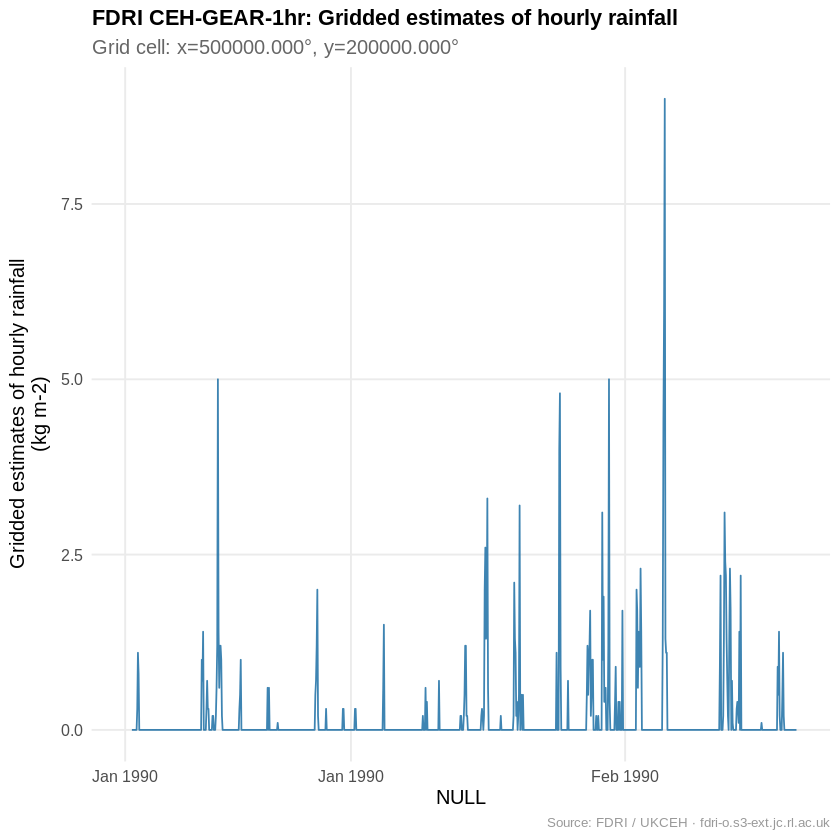

In [ ]:
# ── Plot: full time series ────────────────────────────────────────────────────
y_label <- if (nchar(var_units) > 0) paste0(var_long, "\n(", var_units, ")") else var_long
subtitle_ts <- sprintf("Grid cell: x=%.3f°, y=%.3f°", xs[i_x], ys[i_y])

p_ts <- ggplot(ts_df, aes(x = datetime, y = value)) +
  geom_line(colour = "#1d6fa4", linewidth = 0.5, alpha = 0.85) +
  scale_x_datetime(labels = scales::date_format("%b %Y")) +
  scale_y_continuous(labels = scales::comma) +
  labs(
    title    = paste("FDRI CEH-GEAR-1hr:", var_long),
    subtitle = subtitle_ts,
    x = "NULL",
    y = y_label,
    caption  = "Source: FDRI / UKCEH · fdri-o.s3-ext.jc.rl.ac.uk"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    plot.title    = element_text(face = "bold", size = 13),
    plot.subtitle = element_text(colour = "grey40"),
    panel.grid.minor = element_blank(),
    plot.caption  = element_text(colour = "grey60", size = 8)
  )

print(p_ts)

---
## 4. Spatial map at a single time step

Read the full spatial grid for one time step. Once again as the data is chunked with Zarr, this fetches only the chunks needed for a 2-D slice — much more efficient than downloading the entire array.

You are however likely to run into memory issues on Binder which is limited to 2GB of RAM. Try extracting out only a portion of the whole 2D slice.

In [ ]:
# ── Choose a time step ────────────────────────────────────────────────────────
t_index    <- 1000   # 1000th time step; change as needed
slice_time <- format(datetimes[t_index], "%Y-%m-%d %H:%M UTC")
cat(sprintf("Reading spatial slice for time step %d: %s\n", t_index, slice_time))

n_y <- length(ys)
n_x <- length(xs)

t_index <- as.integer(t_index)
n_y <- as.integer(n_y)
n_x <- as.integer(n_x)
# Read the 2-D slice: [single_time, all_lat, all_lon]
slice_raw <- data_arr$read(selection = list(t_index, seq_len(n_y), seq_len(n_x)))
slice_mat <- matrix(as.numeric(slice_raw), nrow = n_y, ncol = n_x)

cat(sprintf("Grid: %d y × %d x\n", n_y, n_x))
cat(sprintf("Value range: %.3f to %.3f %s\n",
  min(slice_mat, na.rm = TRUE), max(slice_mat, na.rm = TRUE), var_units))

Reading spatial slice for time step 1000: 1990-02-11 15:00 UTC
Grid: 1251 y × 701 x
Value range: 0.000 to 16.300 kg m-2


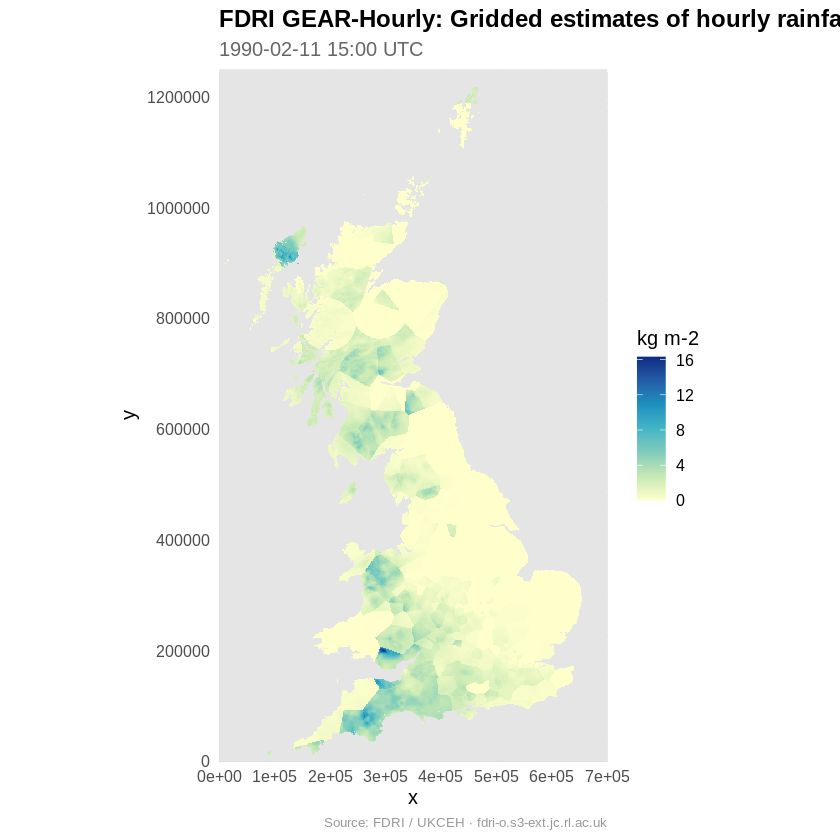

In [ ]:
# ── Build long-format data frame for ggplot2 ──────────────────────────────────
map_df <- expand.grid(x = xs, y = ys)
map_df$value <- as.vector(t(slice_mat)) # transpose

# Get GB/Ireland coastline for overlay
gb <- ne_countries(country = c("United Kingdom", "Ireland"),
                   scale = "medium", returnclass = "sf")

# Clip to the dataset's geographic extent
x_range <- range(xs)
y_range <- range(ys)

p_map <- ggplot() +
  geom_raster(data = map_df,
              aes(x = x, y = y, fill = value), na.rm = TRUE) +
  scale_fill_distiller(
    palette  = "YlGnBu",
    direction = 1,
    name     = var_units,
    na.value = "grey90",
    labels   = scales::comma
  ) +
  coord_sf(
    xlim = x_range,
    ylim = y_range,
    expand = FALSE
  ) +
  labs(
    title    = paste("FDRI GEAR-Hourly:", var_long),
    subtitle = slice_time,
    x = "x", y = "y",
    caption  = "Source: FDRI / UKCEH · fdri-o.s3-ext.jc.rl.ac.uk"
  ) +
  theme_minimal(base_size = 12) +
  theme(
    plot.title    = element_text(face = "bold"),
    plot.subtitle = element_text(colour = "grey40"),
    legend.position = "right",
    panel.grid    = element_line(colour = "grey80", linewidth = 0.2),
    plot.caption  = element_text(colour = "grey60", size = 8)
  )

print(p_map)

In [ ]:
sessionInfo()

---
## Appendix

### Troubleshooting

| Symptom | Fix |
|---------|-----|
| Store opens but `z$arrays` is empty | The store may use consolidated metadata differently — try `z$hierarchy()` to see what was found |
| Variable name not found | Run section 2 to see actual array paths; update `data_var` |
| Dimension order is wrong (map looks transposed) | Swap indices in `data_arr[t, y, x]` to `data_arr[t, x, y]` |
| Time decoding gives wrong dates | Check `time_units` output and adjust `multiplier` manually |
| Data is slow to extract | This is expected over HTTP for large slices/requests. |
| Runtime crashes due to lack of RAM | Reading in large slices of data can cause Colab to run out of memory. Python handles large slices better, try the Python version of this notebook


---

**Data citation:** CEH-GEAR-1hr, UKCEH. https://doi.org/10.5285/dbf13dd5-90cd-457a-a986-f2f9dd97e93c